# Laboratorio #2 — Redes Neuronales Convolucionales (CNN)

**CC3092 · Deep Learning y Sistemas Inteligentes** — Universidad del Valle de Guatemala

**Autor:** Nicolás Concuá

Clasificación de dígitos manuscritos del dataset **MNIST** (0–9). Se construyen,
entrenan y comparan dos arquitecturas: un **MLP** (imagen aplanada) y una **CNN**
(imagen como tensor 2D con capas convolucionales).


## 0. Configuración del entorno

### 0.1 Instalación de dependencias

La siguiente celda instala las librerías necesarias si no están presentes (útil en
Colab o en un entorno nuevo). Si ya las tienes instaladas, puedes omitirla.

In [ ]:
# Descomenta la siguiente línea para instalar las dependencias (p. ej. en Colab o un entorno nuevo):
# !pip install torch torchvision numpy pandas matplotlib scikit-learn

### 0.2 Importaciones y configuración

Importamos las librerías, fijamos una semilla para reproducibilidad y seleccionamos
el dispositivo de cómputo (GPU Apple *MPS* si está disponible, si no CPU).

In [3]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import MNIST
import torchvision.transforms as T

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# --- Reproducibilidad ---
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

# --- Dispositivo ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Dispositivo:", device)

# --- Rutas ---
DATA_DIR      = "../data"
REPORTS_DIR   = "../reports"
ARTIFACTS_DIR = "../reports/artifacts"   # histories + pesos cacheados (no se versiona)
for d in (DATA_DIR, REPORTS_DIR, ARTIFACTS_DIR):
    os.makedirs(d, exist_ok=True)

# Si CACHE=True, un experimento ya entrenado se recarga desde disco en vez de
# volver a entrenarse. Permite re-ejecutar el notebook rápidamente.
CACHE = True

Dispositivo: mps


## 1. Dataset

Trabajamos con **MNIST** (`torchvision.datasets.MNIST`): 70,000 imágenes en escala
de grises de dígitos manuscritos (0–9), divididas oficialmente en 60,000 de
entrenamiento y 10,000 de prueba (*test*).

## 2. Exploración y preparación de los datos

Primero cargamos el dataset **sin normalizar** (solo `ToTensor`, que escala los
píxeles de `[0, 255]` a `[0, 1]`) para responder las preguntas de exploración.

In [4]:
# Carga cruda para exploracion (ToTensor -> [0,1])
raw_train = MNIST(DATA_DIR, train=True,  download=True, transform=T.ToTensor())
raw_test  = MNIST(DATA_DIR, train=False, download=True, transform=T.ToTensor())

print("Imágenes de entrenamiento:", len(raw_train))
print("Imágenes de test:         ", len(raw_test))
print("Clases:                   ", raw_train.classes)
print("Nº de clases:             ", len(raw_train.classes))

Imágenes de entrenamiento: 60000
Imágenes de test:          10000
Clases:                    ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Nº de clases:              10


### 2.1 ¿Cuántas observaciones y clases? ¿Están balanceadas las clases?

,dígito,conteo,porcentaje
0,0,5923,9.87
1,1,6742,11.24
2,2,5958,9.93
3,3,6131,10.22
4,4,5842,9.74
5,5,5421,9.04
6,6,5918,9.86
7,7,6265,10.44
8,8,5851,9.75
9,9,5949,9.92


Mín: 5421  Máx: 6742  Desbalance máx/mín: 1.244


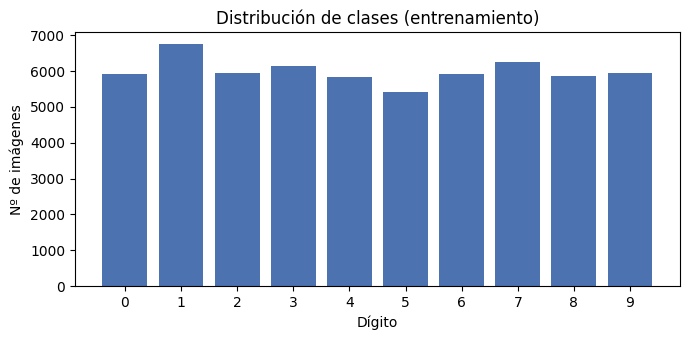

In [5]:
# Conteo de ejemplos por clase en entrenamiento
labels_train = raw_train.targets.numpy()
counts = np.bincount(labels_train, minlength=10)
dist = pd.DataFrame({"dígito": np.arange(10),
                     "conteo": counts,
                     "porcentaje": (counts / counts.sum() * 100).round(2)})
display(dist)
print(f"Mín: {counts.min()}  Máx: {counts.max()}  "
      f"Desbalance máx/mín: {counts.max()/counts.min():.3f}")

plt.figure(figsize=(7,3.5))
plt.bar(np.arange(10), counts, color="#4C72B0")
plt.xticks(np.arange(10)); plt.xlabel("Dígito"); plt.ylabel("Nº de imágenes")
plt.title("Distribución de clases (entrenamiento)")
plt.tight_layout(); plt.show()

**Respuesta.** El dataset tiene **60,000** imágenes de entrenamiento y **10,000**
de test, con **10 clases** (dígitos 0–9). Las clases están **razonablemente
balanceadas**: todas rondan entre ~5,400 y ~6,700 ejemplos (relación máx/mín ≈ 1.2),
por lo que no se requieren técnicas de balanceo.

### 2.2 Dimensión de cada imagen y rango de los píxeles

In [6]:
img, label = raw_train[0]
print("Shape de un ejemplo (C, H, W):", tuple(img.shape))
print("Tipo:", img.dtype)
print("Rango tras ToTensor: min =", img.min().item(), " max =", img.max().item())

# Rango original (0-255) directamente del tensor de datos crudos
print("Rango de píxeles original (uint8):",
      raw_train.data.min().item(), "-", raw_train.data.max().item())

Shape de un ejemplo (C, H, W): (1, 28, 28)
Tipo: torch.float32
Rango tras ToTensor: min = 0.0  max = 1.0
Rango de píxeles original (uint8): 0 - 255


**Respuesta.** Cada imagen es de **28×28 píxeles en 1 canal** (escala de grises),
es decir un tensor `(1, 28, 28)`. Los píxeles originales están en `[0, 255]`
(enteros `uint8`); tras `ToTensor` quedan en `[0.0, 1.0]`.

### 2.3 ¿Es necesario normalizar los valores de los píxeles?

In [7]:
# Media y desviacion estandar del conjunto de entrenamiento (sobre [0,1])
mean = (raw_train.data.float() / 255.0).mean().item()
std  = (raw_train.data.float() / 255.0).std().item()
print(f"Media = {mean:.4f}   Std = {std:.4f}")

Media = 0.1307   Std = 0.3081


**Respuesta.** Sí conviene normalizar. Aunque `ToTensor` ya reescala a `[0, 1]`,
**estandarizar** (restar la media y dividir por la desviación estándar) centra los
datos en torno a 0 con varianza ~1. Esto mejora el condicionamiento del problema de
optimización: los gradientes quedan mejor escalados y el entrenamiento converge más
rápido y de forma más estable. Usaremos los valores canónicos de MNIST
**media = 0.1307** y **std = 0.3081** (equivalentes a los calculados arriba).

### 2.4 Visualización de ejemplos

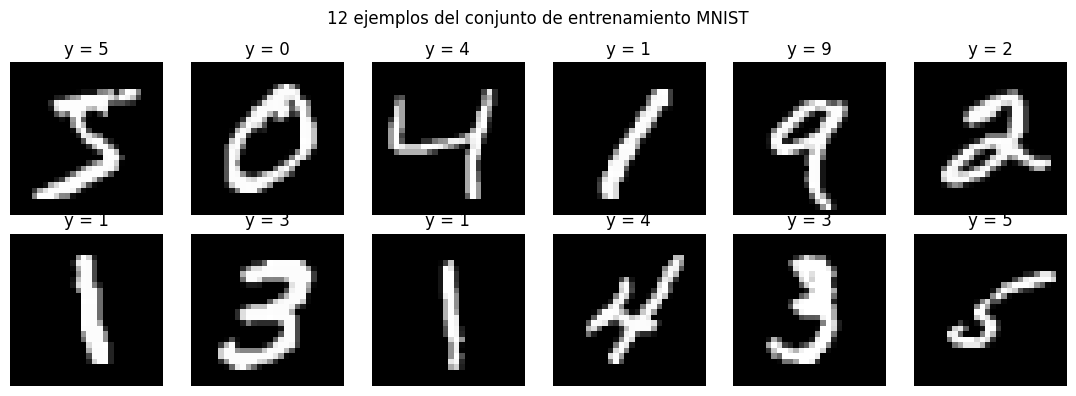

In [8]:
fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for i, ax in enumerate(axes.flat):
    img, label = raw_train[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"y = {label}"); ax.axis("off")
plt.suptitle("12 ejemplos del conjunto de entrenamiento MNIST")
plt.tight_layout(); plt.show()

### 2.5 Preparación: normalización y división train / validación

Definimos la transformación final con **estandarización** y dividimos las 60,000
imágenes de entrenamiento en **54,000 para entrenamiento** y **6,000 para
validación** (90/10) con una semilla fija. El conjunto de **test (10,000)** se
mantiene aparte y solo se usará una vez al final.

In [9]:
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081
transform = T.Compose([T.ToTensor(), T.Normalize((MNIST_MEAN,), (MNIST_STD,))])

full_train = MNIST(DATA_DIR, train=True,  download=True, transform=transform)
test_set   = MNIST(DATA_DIR, train=False, download=True, transform=transform)

n_val = 6000
n_train = len(full_train) - n_val
train_set, val_set = random_split(
    full_train, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED))

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}  |  Test: {len(test_set)}")

Train: 54000  |  Val: 6000  |  Test: 10000


## 3. Investigación: capas de PyTorch para la CNN

Descripción del propósito y los parámetros más relevantes de cada capa de
`torch.nn` utilizada en la CNN.

### `nn.Conv2d`
Aplica una **convolución 2D**: desliza filtros (*kernels*) aprendibles sobre la
imagen para extraer características locales (bordes, texturas, formas). Cada filtro
produce un *feature map*.
- `in_channels` / `out_channels`: canales de entrada y número de filtros (= canales de salida).
- `kernel_size`: tamaño de la ventana del filtro (p. ej. 3×3).
- `stride`: paso del desplazamiento (por defecto 1).
- `padding`: relleno de ceros en los bordes; con `padding=1` y kernel 3×3 se conserva el tamaño espacial.

### `nn.MaxPool2d`
**Submuestreo por máximo**: divide el mapa en ventanas y conserva el valor máximo de
cada una. Reduce la resolución espacial (y el cómputo), aporta cierta invariancia a
pequeñas traslaciones y amplía el campo receptivo.
- `kernel_size`: tamaño de la ventana (p. ej. 2 → reduce a la mitad).
- `stride`: paso (por defecto igual a `kernel_size`).

### `nn.AvgPool2d`
Igual que `MaxPool2d` pero conserva el **promedio** de cada ventana en lugar del
máximo. Suaviza la representación; se usa a veces (como *global average pooling*)
antes del clasificador. Mismos parámetros principales (`kernel_size`, `stride`).

### `nn.BatchNorm2d`
**Normalización por lotes** sobre mapas 2D: normaliza cada canal usando la media y
varianza del *batch*, y aplica un escalado (`γ`) y desplazamiento (`β`) aprendibles.
Estabiliza y acelera el entrenamiento, permite tasas de aprendizaje mayores y actúa
como leve regularizador.
- `num_features`: número de canales de entrada (debe coincidir con los del `Conv2d` previo).

### `nn.Flatten`
**Aplana** un tensor multidimensional a un vector (conservando la dimensión del
*batch*). Sirve de puente entre las capas convolucionales `(N, C, H, W)` y las capas
densas `(N, C·H·W)`. Parámetros: `start_dim` (por defecto 1) y `end_dim`.

### `nn.CrossEntropyLoss`
Función de **pérdida** para clasificación multiclase. Combina internamente
`LogSoftmax` + `NLLLoss`, por lo que **recibe los *logits* crudos** (sin aplicar
softmax) y las etiquetas como índices de clase enteros. Penaliza la divergencia
entre la distribución predicha y la clase verdadera.
- `weight`: pesos por clase (útil ante desbalance).
- `label_smoothing`: suavizado de etiquetas para regularizar.

---

### Conceptos adicionales

**Tensor.** Estructura de datos central de PyTorch: un arreglo n-dimensional
(generalización de escalares, vectores y matrices) que soporta cómputo en
GPU/MPS y **diferenciación automática** (autograd). Las imágenes se representan como
tensores `(N, C, H, W)`.

**Campo receptivo (*receptive field*).** Región de la imagen de entrada que influye
en el cálculo de una neurona/píxel de una capa dada. En las primeras capas es
pequeño (detecta detalles locales) y crece con la profundidad y el *pooling*,
permitiendo que las capas profundas capten patrones cada vez más globales.

**¿Por qué una CNN usa menos parámetros que un MLP equivalente?** Por dos
propiedades: (1) **conectividad local** — cada neurona convolucional se conecta solo
a una pequeña región, no a todos los píxeles; y (2) **compartición de pesos** — el
mismo filtro se reutiliza en toda la imagen. Un filtro 3×3 tiene solo ~9 pesos por
canal y se aplica en todas las posiciones, mientras que una capa densa sobre una
imagen 28×28 requiere 784 pesos **por cada** neurona. Así la CNN captura estructura
espacial con una fracción de los parámetros.